### Notebook Description
This experiment works with UCI's German Credit Data dataset and understanding potential trade-offs between creating a fair model and an accurate model. It aims to understand fairness in the context of gender equality. This is critical for a credit loan data set, seeing as women were not allowed to open banking accounts in their own name until 1974, following the Equal Credit Opportunity Act of 1974. With less establised history, it is important to see if data sets, used to train future models, are making predictions based on gender.

After preparing the data for training, 3 different models are created to understand relationship between accuracy and fairness of prediction models. A baseline model is used to establish the relationship betwen the dataset and its predictors. Then, one baseline model adds features to attemp to improve accuracy, while the other focuses on the hyperparameter tuning of the RandomForestClassifier machine learning model. 

In this experiment, fairness is calculated using the disparate impact test. This is a legal framework used to idntify unintentional discrimination. To do this, we calculate the selection for the protected group, female, and identify if the ratio of protecged group vs. reference group (female vs. male) is less than 0.8. If the ratio is elss than 0.8, it indicates that there likely unintentional disrimination against the protected group. 

### Initial Setup

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
seed = 42
np.random.seed(seed)
random.seed(seed)

In [2]:
df = pd.read_csv('german_credit_data.csv')
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


### Prepare Data for Prediction
UCI's data set includes several columns that are objects. In order to prepare this data for training and prediction, the columns must be first converted from an object to an integer or float value. Based on research of loan evaluation, certain columns are given a truth value (0 or 1) wheras others are given a value from 0 to n, with n being the number of unique values for that column. This is because the options with a column can have a range of "risk" and cannot be simplified to a true or false value. Additionally, data is cleaned to parse for gender, seeing as fairness, in this experiment, is based on gender. A new column is created with the numerical value for simplicity in future training.

In [3]:
# seperate gender from status column
df['gender'] = df['status_and_sex'].apply(lambda x: 'female' if 'female' in x else 'male')

# target: assign 1/0 to good/bad
df['target_num'] = df['target'].map({'good':1, 'bad': 0})

# status_account: assign to 0/1/2/3
status_account_map = {'no checking account': 0, '< 0 DM': 1, '0 to < 200 DM': 2, '>= 200 DM': 3}
df['status_account_num'] = df['status_account'].map(status_account_map)

# is_foreign_worker: assign yes/no to 1/0
df['is_foreign_worker_num'] = df['is_foreign_worker'].map({'yes': 1, 'no':0})

# years_employment: assign to 0/1/2/3/4
df['years_employment'].value_counts()
years_employment_map = {'unemployed':0, '< 1 year': 1, '1 to < 4 years': 2, '4 to < 7 years': 3, '>= 7 years':4}
df['years_employment_num'] = df['years_employment'].map(years_employment_map)

# status_savings: assign to 0/1/2/3/4
status_savings_map = {'unknown/ no savings account': 0, '< 100 DM':1, '100 to < 500 DM': 2, '500 to < 1000DM':3, '>= 1000 DM':4}
df['status_savings_num'] = df['status_savings'].map(status_savings_map)

# credit_history: assign to 0/1/2/3/4
credit_history_map = {'delay in paying off in the past': 0, 'no credits taken/ all credits paid back duly': 1,
                      'all credits at this bank paid back duly': 2, 'existing credits paid back duly till now': 3,
                      'critical account/ other credits existing (not at this bank)': 4}
df['credit_history_num'] = df['credit_history'].map(credit_history_map)

# secondary_obligor: assign to 0/1/2
secondary_obligor_map = {'none': 0, 'co-applicant': 1, 'guarantor':2}
df['secondary_obligor_num'] = df['secondary_obligor'].map(secondary_obligor_map)

# collateral: assign to 0/1/2/3
collateral_map = {'none':0, 'car':1, 'savings agreement/life insurance':2, 'real estate':3}
df['collateral_num'] = df['collateral'].map(collateral_map)

# other_installment_plans: assign to 0/1/2
other_installment_plans_map = {'none':0, 'stores':1, 'banks':2}
df['other_installment_plans_num'] = df['other_installment_plans'].map(other_installment_plans_map)

# housing: make two new columns and assign truth value 1/0 to whether or not house is owned, rented, or neither (both columns 0)
df['housing_own'] = df['housing'].apply(lambda x: 1 if x == 'own' else 0)
df['housing_rent'] = df['housing'].apply(lambda x: 1 if x == 'rent' else 0)

# job: assign to 0/1/2/3
job_map = {'unemployed/ unskilled - non-resident': 0,'unskilled - resident': 1,'skilled employee/ official': 2,'management/ self-employed/highly qualified employee': 3}
df['job_num'] = df['job'].map(job_map)

# telephone: assign to 1/0 for yes/no
telephone_map = {'yes, registered under the customers name': 1,'none': 0}
df['telephone_num'] = df['telephone'].map(telephone_map)

# purpose: make new columns for each purpose listed in the dataset
df_purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True)
df = pd.concat([df, df_purpose_dummies], axis=1)

The data frame now has columns for both object and numerical/truth value. The cleaned data frame only includes the columns that are numerical or boolean.

In [4]:
# 
cols_dropped = ['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment',
               'status_and_sex', 'secondary_obligor', 'collateral','target', 'other_installment_plans', 'housing',
               'job', 'telephone', 'is_foreign_worker']
df_cleaned = df.drop(columns = cols_dropped)
df_cleaned.head()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,gender,target_num,status_account_num,...,telephone_num,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining
0,6,1169,4,4,67,2,1,male,1,1,...,1,False,False,False,False,False,False,True,False,False
1,48,5951,2,2,22,1,1,female,0,2,...,0,False,False,False,False,False,False,True,False,False
2,12,2096,2,3,49,1,2,male,1,0,...,0,False,False,False,True,False,False,False,False,False
3,42,7882,2,4,45,1,2,male,1,1,...,0,False,False,False,False,True,False,False,False,False
4,24,4870,3,4,53,2,2,male,0,1,...,0,True,False,False,False,False,False,False,False,False


### Create Train Test Splits
Cleaned data set must be partitioned into training and testing to build a model and then test it with the remaining data. An 80-20 train test split will be used for this data set.

In [5]:
X = df_cleaned.drop(columns = ['gender', 'target_num'])
y = df_cleaned['target_num']
gender_attr = df['gender']

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X,y, gender_attr, test_size = 0.2, random_state = seed, stratify = y
)

Next, features with numbers that are not a boolean are scaled to ensure all features contribute equally to the model.

In [6]:
# identify features that need to be scaled
num_cols = ['month_duration', 'credit_amount', 'payment_to_income_ratio', 'age', 
            'status_account_num', 'status_savings_num', 'years_employment_num', 
            'credit_history_num', 'job_num']
scaler = StandardScaler()

# make copy for scaling
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

### Train Baseline Model

In [7]:
# baseline model that does not account for gender in prediction
model = RandomForestClassifier(n_estimators = 100, random_state = seed)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("--- Model Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Accuracy Score: 72.50%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.56      0.42      0.48        60
           1       0.77      0.86      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.64      0.64       200
weighted avg       0.71      0.72      0.71       200



This checks for the relative importance of features for credit scoring from the baseline model

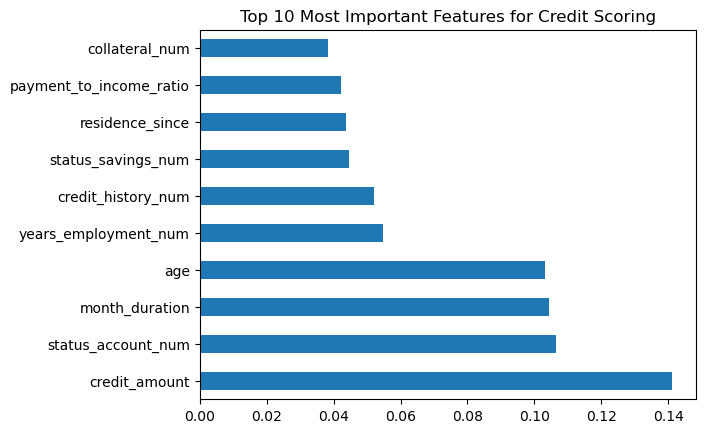

In [8]:
# check feature importance
importances = pd.Series(model.feature_importances_, index = X.columns)
importances.nlargest(10).plot(kind = 'barh')
plt.title("Top 10 Most Important Features for Credit Scoring")
plt.show()

### Fairness Evaluation of Model by Gender

In [9]:
eval_df = pd.DataFrame({'actual':y_test, 'predicted':y_pred, 'gender':gender_test})
selection_rate = eval_df.groupby('gender')['predicted'].mean()
print("--- Selection Rates (Loan Approval %) ---")
print(selection_rate)

# disparate impact ratio (threshold = 80%)
di_ratio = selection_rate.min() / selection_rate.max()
print(f"\nDisparate Impact Ratio: {di_ratio:.4f}")

--- Selection Rates (Loan Approval %) ---
gender
female    0.766667
male      0.778571
Name: predicted, dtype: float64

Disparate Impact Ratio: 0.9847


In [10]:
# check false positive rate
for g in eval_df['gender'].unique():
    subset = eval_df[eval_df['gender'] == g]
    cm = confusion_matrix(subset['actual'], subset['predicted'])
    # False Positive Rate = FP / (FP + TN)
    fpr = cm[0,1] / (cm[0,1] + cm[0,0])
    print(f"False Positive Rate for {g}: {fpr:.4f}")

False Positive Rate for male: 0.6250
False Positive Rate for female: 0.5000


### Understanding Tradeoff between Accuracy and Fairness
Working off this baseline model, there are different measures to try and improve accuracy of the prediction. Different models will be tested to evaluate their accuracy and fairness.

### Model 2: Adding prediction features
There are instances where columns may be related. Second model considers monthly payment wheras credit amount as as a whole and the overall burden of an individual. Additionally, stability score is assigned by considering duration of residence and number of years employed. Typically, longer history at one address and more years employed is a good indicator of financial stability.

In [11]:
# calculate estimated monthly payment burden
df_cleaned['monthly_payment'] = df_cleaned['credit_amount'] / df_cleaned['month_duration']
df_cleaned['relative_burden'] = df_cleaned['monthly_payment'] * df_cleaned['payment_to_income_ratio']

# a good indicator of stability is how long someone has been in residence and their employment
df_cleaned['stability_score'] = df_cleaned['residence_since'] + df_cleaned['years_employment_num']

# make new train test split
X2 = df_cleaned.drop(columns = ['gender', 'target_num'])
y2 = df_cleaned['target_num']
gender_attr = df['gender']

X2_train, X2_test, y2_train, y2_test, gender_train2, gender_test2 = train_test_split(
    X2,y2, gender_attr, test_size = 0.2, random_state = seed, stratify = y)

# scale new features
num_cols2 = ['month_duration', 'credit_amount', 'payment_to_income_ratio', 'age', 
            'status_account_num', 'status_savings_num', 'years_employment_num', 
            'credit_history_num', 'job_num', 'stability_score', 'monthly_payment',
             'relative_burden']
scaler = StandardScaler()

# make new copy for scaling
X2_train_scaled = X2_train.copy()
X2_test_scaled = X2_test.copy()

X2_train_scaled[num_cols2] = scaler.fit_transform(X2_train[num_cols2])
X2_test_scaled[num_cols2] = scaler.transform(X2_test[num_cols2])

# train model 2
model2 = RandomForestClassifier(n_estimators = 100, random_state = seed)
model2.fit(X2_train_scaled, y2_train)
y2_pred = model2.predict(X2_test_scaled)

print("--- Model Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y2_test, y2_pred):.2%}")
print("\n--- Classification Report ---")
print(classification_report(y2_test, y2_pred))

--- Model Accuracy ---
Accuracy Score: 73.00%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.38      0.46        60
           1       0.77      0.88      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.63      0.64       200
weighted avg       0.71      0.73      0.71       200



In [12]:
# check importance of features
importances = pd.Series(model2.feature_importances_, index=X2_train.columns)
print(importances.sort_values(ascending=False).head(10))

monthly_payment         0.108696
credit_amount           0.108110
status_account_num      0.092706
relative_burden         0.088879
age                     0.076918
month_duration          0.075358
credit_history_num      0.042152
stability_score         0.042032
status_savings_num      0.035308
years_employment_num    0.032503
dtype: float64


In [13]:
# fairness evaluation for model 2
eval2_df = pd.DataFrame({'actual':y2_test, 'predicted':y2_pred, 'gender':gender_test2})
selection_rate2 = eval2_df.groupby('gender')['predicted'].mean()
print("--- Selection Rates (Loan Approval %) ---")
print(selection_rate2)

# disparate impact ratio (threshold = 80%)
di_ratio2 = selection_rate2.min() / selection_rate2.max()
print(f"\nDisparate Impact Ratio: {di_ratio2:.4f}")

--- Selection Rates (Loan Approval %) ---
gender
female    0.766667
male      0.814286
Name: predicted, dtype: float64

Disparate Impact Ratio: 0.9415


In [14]:
# check for false positives
for g in eval2_df['gender'].unique():
    subset = eval2_df[eval2_df['gender'] == g]
    cm = confusion_matrix(subset['actual'], subset['predicted'])
    # False Positive Rate = FP / (FP + TN)
    fpr = cm[0,1] / (cm[0,1] + cm[0,0])
    print(f"False Positive Rate for {g}: {fpr:.4f}")

False Positive Rate for male: 0.6750
False Positive Rate for female: 0.5000


### Attempt 2: Hyperparameter Tuning
The first 2 models use the RandomForestClassifer to make the model. In this attempt, the RandomForestClassifer algorithm is examined to find the best parameters to make a new model. The data with added features is then trained on these best estimators and new calculates are made for accuracy and fairness.

In [15]:
param_dist = {
    'n_estimators': [100, 300, 500],           # Number of trees
    'max_depth': [5, 10, 20, None],            # How deep each tree can go
    'min_samples_split': [2, 5, 10],           # Minimum data points to make a split
    'max_features': ['sqrt', 'log2', None],    # How many features to look at per split
    'criterion': ['gini', 'entropy']           # How to measure the "quality" of a split
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20, # Try 20 different combinations
    cv=5,      # 5-fold cross-validation
    random_state=seed,
    n_jobs=-1  
)

rf_random.fit(X2_train_scaled, y2_train)

print(f"Best parameters found: {rf_random.best_params_}")

Best parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy'}


In [16]:
# make new model based on the best parameters found
best_model = rf_random.best_estimator_
new_pred = best_model.predict(X2_test_scaled)
print(f"Tuned Accuracy: {accuracy_score(y2_test, new_pred):.2%}")

Tuned Accuracy: 72.00%


In [17]:
# check fairness of new model
eval3_df = pd.DataFrame({'actual':y2_test, 'predicted':new_pred, 'gender':gender_test2})
selection_rate3 = eval3_df.groupby('gender')['predicted'].mean()
print("--- Selection Rates (Loan Approval %) ---")
print(selection_rate3)

# disparate impact ratio (threshold = 80%)
di_ratio3 = selection_rate3.min() / selection_rate3.max()
print(f"\nDisparate Impact Ratio: {di_ratio3:.4f}")

--- Selection Rates (Loan Approval %) ---
gender
female    0.800000
male      0.857143
Name: predicted, dtype: float64

Disparate Impact Ratio: 0.9333


In [18]:
# check false positives
for g in eval3_df['gender'].unique():
    subset = eval3_df[eval3_df['gender'] == g]
    cm = confusion_matrix(subset['actual'], subset['predicted'])
    # False Positive Rate = FP / (FP + TN)
    fpr = cm[0,1] / (cm[0,1] + cm[0,0])
    print(f"False Positive Rate for {g}: {fpr:.4f}")

False Positive Rate for male: 0.7500
False Positive Rate for female: 0.6000


### SUMMARY OF FINDINGS

In [19]:
# function for summary statistics of the models
def evaluate_model_performance(model, X_test, y_test, gender_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # calculates selection rate by gender
    results_df = pd.DataFrame({'actual': y_test, 'predicted': y_pred, 'gender': gender_test})
    
    male_sel = results_df[results_df['gender'] == 'male']['predicted'].mean()
    female_sel = results_df[results_df['gender'] == 'female']['predicted'].mean()
    
    # calculates disparate impact
    di = female_sel / male_sel if male_sel != 0 else 0
    
    return {
        'Accuracy': round(acc, 4),
        'Disparate Impact (DI)': round(di, 4),
        'Total False Positives': fp,
        'Male Selection Rate': round(male_sel, 4),
        'Female Selection Rate': round(female_sel, 4)
    }

In [20]:
# call results table
results = {
    'Baseline': evaluate_model_performance(model, X_test_scaled, y_test, gender_test),
    'Added Features': evaluate_model_performance(model2, X2_test_scaled, y2_test, gender_test2),
    'Tuned Model': evaluate_model_performance(best_model, X2_test_scaled, y2_test, gender_test2)
}
comparison_df = pd.DataFrame(results)

print("--- Final Model Comparison ---")
display(comparison_df)

--- Final Model Comparison ---


,Baseline,Added Features,Tuned Model
Accuracy,0.7250,0.7300,0.7200
Disparate Impact (DI),0.9847,0.9415,0.9333
Total False Positives,35.0000,37.0000,42.0000
Male Selection Rate,0.7786,0.8143,0.8571
Female Selection Rate,0.7667,0.7667,0.8000


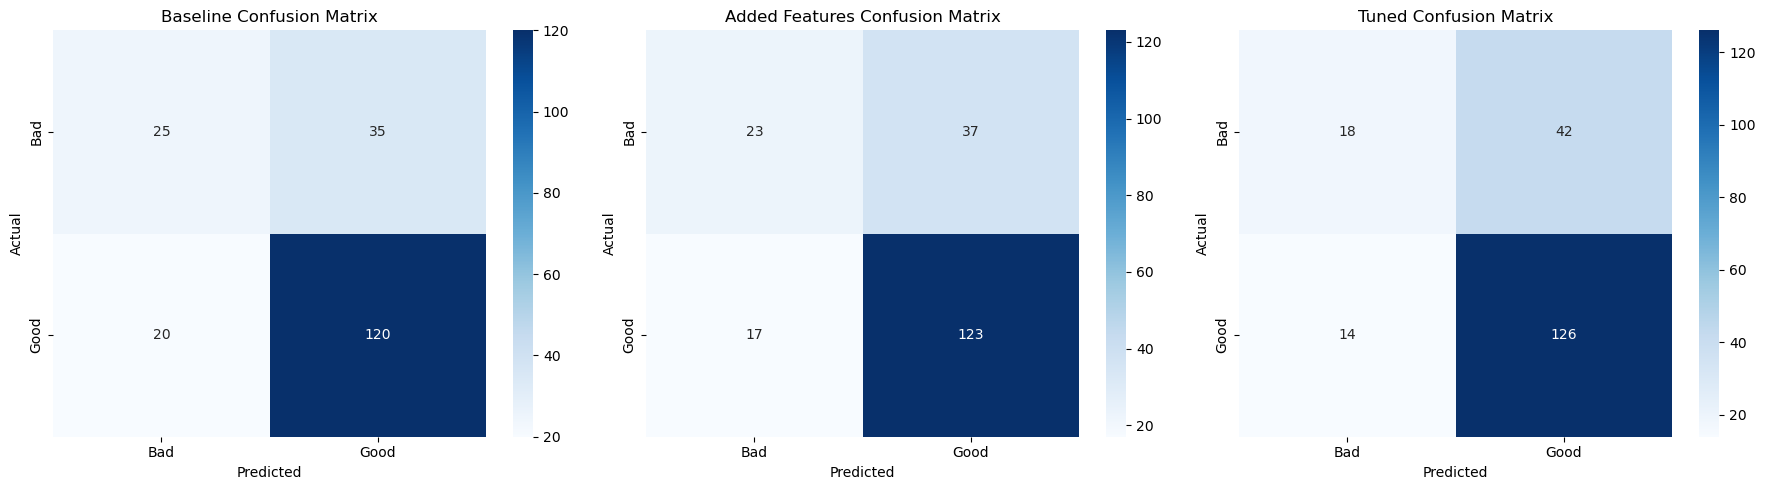

In [21]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Example for the 3 models (replace predictions with your variables)
all_preds = [y_pred, y2_pred, new_pred]
model_names = ['Baseline', 'Added Features', 'Tuned']

for i, pred in enumerate(all_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    axes[i].set_title(f'{model_names[i]} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Discussion
The baseline model has accuracy of 72.5% and disparate impact ratio of 0.9847. The DI ratio is above the 0.80 threshold, indicating that the model is fair and not discriminatory based on gender. The added features model has accuracy of 73% and disparate impact ratio of 0.9415. We can see than the DI ratio is lower than the baseline model, but still within the range of a fair model. Lastly, the tuned model has accuracy of 72% and disparate impact ratio of 0.9333. The last model is interesting, seeing as both accuracy and DI ratio is lower than the first two models. As such, this model may not be the best to evaluate, seeing as both accuracy and disparate impact is lowest among the three models.

The first two models may serve as an indicator that, for accuracy to increase, the disparate impact ratio may decrease. In this scenario, the accuracy does not change by much, and the both DI ratios are still well above the 0.8 threshold for the disparate impact framework. However, it will be interested to see that, if accuracy could further improve, whether DI could continue to drop to a level below the acceptable threshold. 

These models also indicate that the initial set i